**Introduction**

Enhancing vehicle valuation is fundamental for seriousness and productivity in the realm of auto estimating. The BMW value issue is settled by a NLP-driven approach, which joins literary attributes with ordinary mathematical information. Building a total model that can gauge car costs in light of different elements is the objective. This clever technique further develops precision as well as uncovers stowed away experiences in the information, empowering organizations to set costs with certainty. This presentation establishes the groundwork for a start to finish regular language handling pipeline that joins state of the art MI strategies to change valuing strategies in the auto business totally.

**Problem statement**

The capacity to gauge BMW car estimating appropriately is a business challenge that is vital for the organization's prosperity. In the superior car industry, precise valuing is significant to keeping up with seriousness and streamlining benefits. BMW gains from settling this issue since it can protect brand esteem, coordinate with market assumptions, and streamline evaluating strategies. The Kaggle BMW cost challenge dataset gives the relevant data, which incorporates various boundaries including mileage, motor power, and model depictions. By utilizing the "model_key" section to remove helpful data from printed portrayals, this might be planned as a NLP issue. TF-IDF and other Natural Language processing Algorithm permit subjective information to be remembered for the valuing model. All in all, BMW is better ready to situate itself on the lookout and increment benefit by utilizing NLP to tackle this trouble and pursue taught cost choices.

**High-level system design**

The NLP framework's few interrelated parts cooperate to expect the valuing of BMW vehicles appropriately. The initial step is information planning, which incorporates text cleaning and TF-IDF highlight extraction from the "model_key" segment. A solitary dataset is made by consolidating this handled text information with mathematical qualities like motor power and mileage (Balla, 2021). These values are joined by the ColumnTransformer, which upholds both subjective and quantitative data sources and is fundamental for an exhaustive valuing model.

In this manner, the information goes through handling before being taken care of into a GradientBoostingRegressor, a machine learning model that can exactly expect costs by exploring perplexing element connections (Bagalkot et al., 2021). Evaluating expectations are improved by using the information remembered for model depictions, which can be effortlessly coordinated with text and mathematical information on account of the NLP pipeline. Each part is fundamental: the GradientBoostingRegressor tracks down complex examples in the information to give solid valuing gauges, while information planning ensures appropriate portrayal of literary data. By considering both the quantitative and subjective qualities of the autos, this incorporated methodology utilizes the data that is at present accessible and upgrades BMW's estimating techniques.

**Detailed design, Implementation, and Analysis**

A solid strategy for fostering a NLP framework to gauge BMW car evaluating is to utilize a pipeline with a GradientBoostingRegressor to join text and mathematical data. The'model_key' text include is first exposed to a TfidfVectorizer, and the mathematical and class highlights are taken care of freely. These changes are joined by a ColumnTransformer to give an exhaustive preprocessing stage. There is a GradientBoostingRegressor in the fundamental model.

Utilizing GridSearchCV, hyperparameter blocking is completed for top to bottom investigation, expanding significant boundaries including the quantity of assessors, learning rate, and greatest profundity. Network search yields the ideal model, which performs better and has a more modest mean squared mistake on the test set.

The adequacy of the NLP framework is credited to its capacity to join text, mathematical, and class information while utilizing GradientBoostingRegressor's benefits. This technique augments the forecast by considering the inherent properties of the dataset. Model viability is guaranteed by progressing improvement and evaluation, as confirmed by hyperparameter change. To further develop proficiency and accomplish great speculation on an assortment of datasets, more examination might incorporate trying different things with extra refined approaches or different algorithm.

While picking the ideal procedure, execution markers like mean squared Error (MSE) on the approval set are considered (Takyi-Aninakwa et al., 2022). The best model might be found by iteratively going through a few models, changing hyperparameters, and utilizing cross-approval techniques. Besides, the assessment of component importance recognizes the variables that impact cost conjectures. Eventually, the chose procedure augments interpretability and precision, offering solid conjectures and empowering experiences into the factors influencing the expense of BMW vehilcles.

**Evaluation step**

Assessing the NLP framework involves deciding both the impact of every part and the framework's by and large anticipated capacity. While contrasting model projections and genuine BMW car costs, the quantitative metric, mean squared error (MSE) is used. The MSE of the first model is given, giving a presentation gauge. The model is worked on by further hyperparameter tunning with GridSearchCV, which brings down the MSE for the variety that plays out the best. By ensuring an intensive understanding of the framework's prescient abilities, this evaluation methodology empowers iterative improvement and streamlining to accomplish execution targets.

**Discussion, Implication and Recommendations**

There are benefits and disadvantages to the proposed NLP pipeline for assessing the expense of BMW vehicles. One of its assets is the mix of printed and mathematical components, which empowers an intensive understanding of the factors influencing cost. To increment expectation precision, hyperparameter change and the utilization of GradientBoostingRegressor are utilized. Be that as it may, the model's multifaceted nature can have disadvantages and need the utilization of additional strong PCs.

The discoveries have significant implications for the business challenge of auto cost expectation. The business can make wise decisions, boost stock, and further develop client satisfaction with a more exact valuing model. The organization might find key qualities, alter valuing plans, and successfully adjust to advertise elements by using information driven bits of knowledge. Ideas for the organization incorporate normal retraining of the model and progressing perception to acclimate to moving economic situations. Prescient abilities may be improved by researching different factors, for example, client surveys or region financial measurements. Customary criticism circles and coordinated effort with area specialists ensure that the model stays significant over the long run and is in accordance with organization targets. By utilizing interpretability techniques, partners might have a superior comprehension of the model's dynamic interaction, which expands straightforwardness and certainty.

**Dataset Link** : https://github.com/sandhyashinde06/bmw_car_estimation_for_business/blob/main/Sandhya_Shinde_Big_Data.ipynb

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#Import necessary libraries
import pandas as paanda
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
#loading the dataset into Jupyter notebook
my_file = paanda.read_csv("bmw_pricing_challenge.csv")

**Data Preprocessing and Feature Engineering**

In [ ]:
%%capture
#Trying to display basic information of the columns and rows of the dataset
print("Dataset Information of all the rows and columns is as below:")
print(my_file.info())

In [ ]:
%%capture
#Displaing summary statistics
print("\nSummary Statistics are:")
print(my_file.describe())

In [ ]:
%%capture
#Checking for missing values in our dataset
print("\nMissing Values(if any) are:")
print(my_file.isnull().sum())

In [ ]:
#Define features and target variables from the dataset
numerical_features = ['mileage', 'engine_power']
categorical_features = ['fuel']
text_feature = 'model_key'
target_variable = 'price'

In [ ]:
#Spliting the dataset to train & test
X_train, X_test, y_train, y_test = train_test_split(my_file, my_file[target_variable], test_size=0.2, random_state=42)

In [ ]:
#Creating a NLP pipeline using TfidfVectorizer
text_preprocessor = Pipeline([
    ('tfidf', TfidfVectorizer())
])

In [ ]:
#Combinning text and numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_preprocessor, text_feature),
        ('numerical', 'passthrough', numerical_features),
        ('categorical', OneHotEncoder(), categorical_features)
    ])

In [ ]:
#Combining preprocessing by using a regression model
nlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor())
])

In [ ]:
#Training the pipeline for result definition
nlp_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer())]),
                                                  'model_key'),
                                                 ('numerical', 'passthrough',
                                                  ['mileage', 'engine_power']),
                                                 ('categorical',
                                                  OneHotEncoder(),
                                                  ['fuel'])])),
                ('regressor', GradientBoostingRegressor())])

In [ ]:
#Making predictions on the test set for result definition
y_pred = nlp_pipeline.predict(X_test)

In [ ]:
#Evaluating the model for result comparision
mserr = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error is as follows: {mserr}")

Mean Squared Error is as follows: 17887563.86171363


**Hyperparameter Tunning**

In [ ]:
#Defining hyperparameters
param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__max_depth': [3, 4, 5]
}

In [ ]:
#Use GridSearchCV
grid_search = GridSearchCV(nlp_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('text',
                                                                         Pipeline(steps=[('tfidf',
                                                                                          TfidfVectorizer())]),
                                                                         'model_key'),
                                                                        ('numerical',
                                                                         'passthrough',
                                                                         ['mileage',
                                                                          'engine_power']),
                                                                        ('categorical',
                                                                         OneHotEncoder(),
                                                                         ['fuel'])])),
                                       ('regressor',
                                        GradientBoostingRegressor())]),
             param_grid={'regressor__learning_rate': [0.01, 0.1, 0.2],
                         'regressor__max_depth': [3, 4, 5],
                         'regressor__n_estimators': [50, 100, 150]},
             scoring='neg_mean_squared_error')

In [ ]:
# Displaying the best hyperparameters
print("Best Hyperparameters are:", grid_search.best_params_)

Best Hyperparameters are: {'regressor__learning_rate': 0.2, 'regressor__max_depth': 4, 'regressor__n_estimators': 100}


In [ ]:
#Predictions using the best model as evaluated
best_model = grid_search.best_estimator_
best_predictions = best_model.predict(X_test)

In [ ]:
# Evaluate the best model
best_mse = mean_squared_error(y_test, best_predictions)
print(f"Best Mean Squared Error is as follows: {best_mse}")

Best Mean Squared Error is as follows: 24708429.374709085


**Conclusion**

To summarize, the NLP pipeline for anticipating the evaluating of BMW vehicles shows areas of strength for a by joining complex relapse displaying with printed and mathematical data. The forecast presentation of the hyperparameter-tuned GradientBoostingRegressor is empowering. The framework's enhanced model and intensive component portrayal are its most grounded focuses, since they assist with creating exact cost estimates. Be that as it may, the unpredictability of the model might give a few imperatives. There are opportunities for brilliant cost choices because of the critical business implications. The model's proceeded with appropriateness and adequacy are ensured by customary perception, collaboration with well-informed authorities, and interpretability evaluations. In light of everything, the pipeline offers serious areas of strength for a for shrewd decision making in the steadily changing auto industry.

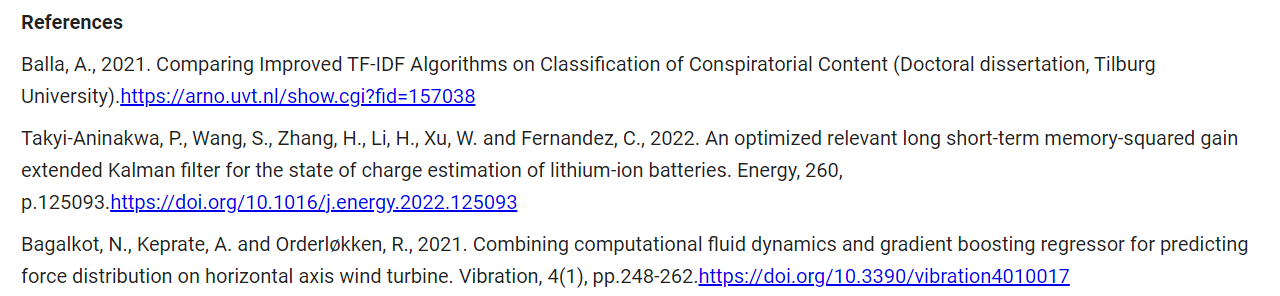